<a href="https://colab.research.google.com/github/promckkon/MK2DimCNN/blob/main/Cover%20rate%20260504.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# =========================================================
# Cell 1: 環境配置與套件載入 (Environment & Setup)
# =========================================================
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore') # 隱藏 Pandas FutureWarning 等

# 自動檢查並修復 CatBoost 與 NumPy 版本衝突
try:
    import catboost
    import numpy as np
    if catboost.__version__ != '1.2.7' or np.__version__ >= '2.0.0':
        raise ImportError
except:
    print("正在安裝穩定版環境 (NumPy 1.26.4 & CatBoost 1.2.7)...")
    get_ipython().system('pip install -q "numpy==1.26.4" "catboost==1.2.7" "scipy" "scikit-learn" "seaborn" "matplotlib"')
    print("--- 安裝完成！請點擊上方選單「執行階段」->「重新啟動執行階段」，然後再次執行此單元格 ---")

import scipy.io
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

# 🌟 [修改點 1] 加入了 mutual_info_score (互資訊)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mutual_info_score
from sklearn.manifold import TSNE
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt

# 🌟 [修改點 2] 加入了 entropy (資訊熵)
from scipy.stats import skew, kurtosis, entropy

import datetime
import random
import itertools # 🌟 [修改點 3] 加入 itertools，用來跑 6x6 矩陣的排列組合

print("✅ 所有套件與高級特徵計算工具載入完成，準備就緒！")

✅ 所有套件與高級特徵計算工具載入完成，準備就緒！


📂 階段 1: 正在從硬碟預先載入所有 .mat 檔案...
✅ 載入成功！共 10 種故障類別。準備進入 36 組實驗矩陣...

🧪 實驗 1/49 | Window: 1000, Overlap: 30% (Stride: 700)... 完成！準確率: 0.8917, 耗時: 29.9s
🧪 實驗 2/49 | Window: 1000, Overlap: 40% (Stride: 600)... 完成！準確率: 0.9076, 耗時: 33.5s
🧪 實驗 3/49 | Window: 1000, Overlap: 50% (Stride: 500)... 完成！準確率: 0.9108, 耗時: 39.0s
🧪 實驗 4/49 | Window: 1000, Overlap: 60% (Stride: 400)... 完成！準確率: 0.9045, 耗時: 45.8s
🧪 實驗 5/49 | Window: 1000, Overlap: 70% (Stride: 300)... 完成！準確率: 0.9045, 耗時: 60.4s
🧪 實驗 6/49 | Window: 1000, Overlap: 80% (Stride: 199)... 完成！準確率: 0.9108, 耗時: 85.6s
🧪 實驗 7/49 | Window: 1000, Overlap: 90% (Stride: 99)... 完成！準確率: 0.9204, 耗時: 164.5s
🧪 實驗 8/49 | Window: 1200, Overlap: 30% (Stride: 840)... 完成！準確率: 0.9045, 耗時: 25.6s
🧪 實驗 9/49 | Window: 1200, Overlap: 40% (Stride: 720)... 完成！準確率: 0.9172, 耗時: 28.1s
🧪 實驗 10/49 | Window: 1200, Overlap: 50% (Stride: 600)... 完成！準確率: 0.9299, 耗時: 32.0s
🧪 實驗 11/49 | Window: 1200, Overlap: 60% (Stride: 480)... 完成！準確率: 0.9427, 耗時: 39.3s
🧪 實驗 12/49 | Window: 1200, Ov

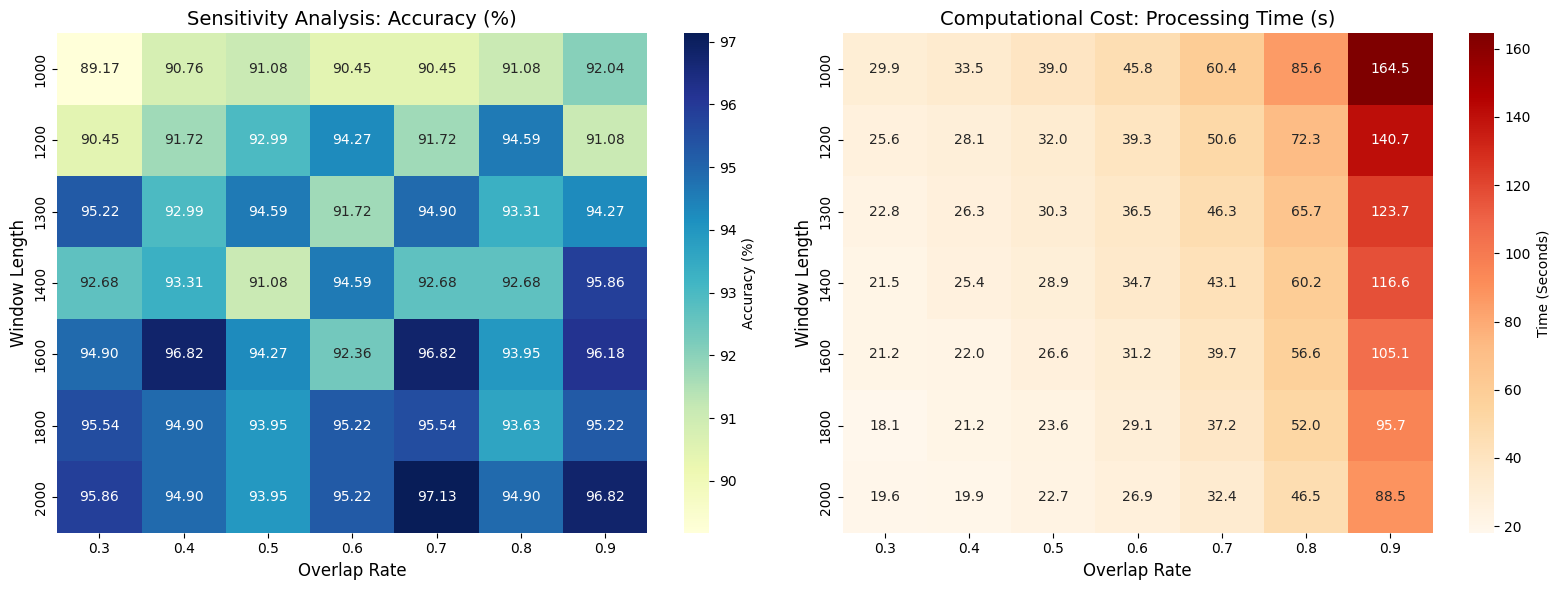

In [38]:
# =========================================================
# 終極敏感度分析矩陣 (視窗長度 vs. 重疊率) - All-in-One 完整版
# 包含 12 項統計特徵與雙熱力圖自動繪製
# =========================================================
import os
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, entropy
from sklearn.metrics import mutual_info_score
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
import time
import itertools

# ---------------------------------------------------------
# 1. 參數設定與實驗網格
# ---------------------------------------------------------
MAT_FOLDER_PATH = "/content/drive/MyDrive/CWRU_with_NOISE/CWRU_2" # 請確認你的路徑
WINDOW_LENGTHS = [1000, 1200, 1300, 1400, 1600, 1800, 2000]
OVERLAP_RATES = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

TARGET_BALANCED_ROWS = 1570 # 資料平衡的總目標筆數

# ---------------------------------------------------------
# 2. 資料預先載入 (只讀一次，加速後續迴圈)
# ---------------------------------------------------------
print("📂 階段 1: 正在從硬碟預先載入所有 .mat 檔案...")
df_list = []
for root, dirs, files in os.walk(MAT_FOLDER_PATH, topdown=False):
    for file_name in files:
        if file_name.endswith('.mat'):
            path = os.path.join(root, file_name)
            mat = scipy.io.loadmat(path)
            key_name = list(mat.keys())[3]
            df_temp = pd.DataFrame({'DE_data': np.ravel(mat.get(key_name)), 'fault': file_name[:-4]})
            df_list.append(df_temp)

if not df_list:
    raise ValueError(f"❌ 找不到資料！請檢查路徑: {MAT_FOLDER_PATH}")

df_all = pd.concat(df_list, ignore_index=True)
fault_types = df_all['fault'].unique()
samples_per_class = TARGET_BALANCED_ROWS // len(fault_types)
print(f"✅ 載入成功！共 {len(fault_types)} 種故障類別。準備進入 36 組實驗矩陣...\n")

# ---------------------------------------------------------
# 3. 核心實驗迴圈
# ---------------------------------------------------------
results = []
total_experiments = len(WINDOW_LENGTHS) * len(OVERLAP_RATES)
current_exp = 0

for win_len, overlap in itertools.product(WINDOW_LENGTHS, OVERLAP_RATES):
    current_exp += 1
    stride = int(win_len * (1 - overlap))
    print(f"🧪 實驗 {current_exp}/{total_experiments} | Window: {win_len}, Overlap: {overlap*100:.0f}% (Stride: {stride})...", end=" ")

    start_time = time.time()
    stats_list, y_list = [], []

    # [特徵提取]
    for f in fault_types:
        fault_data = df_all[df_all['fault'] == f]['DE_data'].values.astype(float)
        num_windows = (len(fault_data) - win_len) // stride + 1

        for i in range(num_windows):
            window = fault_data[i*stride : i*stride + win_len].flatten()
            y_list.append(f)

            # 計算 12 項特徵
            rms = np.sqrt(np.mean(np.square(window)))
            mean_abs = np.mean(np.abs(window))

            # 熵
            counts, _ = np.histogram(window, bins=20)
            ent = entropy(counts + 1e-9)

            # Lag-1 自相關與互資訊
            lag1_corr = np.corrcoef(window[:-1], window[1:])[0, 1] if np.std(window) > 0 else 0
            c_xy, _, _ = np.histogram2d(window[:-1], window[1:], bins=20)
            lag1_mi = mutual_info_score(None, None, contingency=c_xy)

            stats_list.append([
                np.mean(window), np.std(window), rms, np.max(window), np.min(window),
                skew(window), kurtosis(window),
                rms / mean_abs if mean_abs != 0 else 0, np.max(window) / rms if rms != 0 else 0,
                ent, lag1_corr, lag1_mi
            ])

    # [資料平衡]
    temp_df = pd.DataFrame({'stats': stats_list, 'fault': y_list})
    resampled_data = [resample(temp_df[temp_df['fault'] == f],
                               replace=(len(temp_df[temp_df['fault'] == f]) < samples_per_class),
                               n_samples=samples_per_class, random_state=42) for f in fault_types]
    balanced_df = pd.concat(resampled_data).sample(frac=1, random_state=42).reset_index(drop=True)

    X = np.stack(balanced_df['stats'].values)
    y = balanced_df['fault'].values

    # [輕量化模型訓練]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = CatBoostClassifier(iterations=100, depth=6, loss_function='MultiClass',
                               eval_metric='Accuracy', verbose=0, random_seed=42, thread_count=-1)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))

    end_time = time.time()
    time_taken = end_time - start_time

    print(f"完成！準確率: {acc:.4f}, 耗時: {time_taken:.1f}s")

    # 紀錄結果
    results.append({
        'Window Length': win_len,
        'Overlap Rate': overlap,
        'Accuracy': acc * 100, # 轉為百分比
        'Time (s)': time_taken
    })

# ---------------------------------------------------------
# 4. 結果保存與繪製熱力圖
# ---------------------------------------------------------
results_df = pd.DataFrame(results)
results_df.to_csv('sensitivity_matrix_results.csv', index=False)
print("\n💾 所有實驗完成！結果已儲存至 'sensitivity_matrix_results.csv'")

# 準備矩陣資料供熱力圖使用
acc_matrix = results_df.pivot(index='Window Length', columns='Overlap Rate', values='Accuracy')
time_matrix = results_df.pivot(index='Window Length', columns='Overlap Rate', values='Time (s)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 圖 1: 準確率熱力圖
sns.heatmap(acc_matrix, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0], cbar_kws={'label': 'Accuracy (%)'})
axes[0].set_title('Sensitivity Analysis: Accuracy (%)', fontsize=14)
axes[0].set_xlabel('Overlap Rate', fontsize=12)
axes[0].set_ylabel('Window Length', fontsize=12)

# 圖 2: 訓練耗時熱力圖
sns.heatmap(time_matrix, annot=True, fmt=".1f", cmap="OrRd", ax=axes[1], cbar_kws={'label': 'Time (Seconds)'})
axes[1].set_title('Computational Cost: Processing Time (s)', fontsize=14)
axes[1].set_xlabel('Overlap Rate', fontsize=12)
axes[1].set_ylabel('Window Length', fontsize=12)

plt.tight_layout()
plt.show()